<a href="https://colab.research.google.com/github/roshank1605A04/Twitter-Sentiment-Analysis/blob/master/Twitter_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/TEJASHREE K/Certified Data Science/05-Advance Data Science/LMS_ADS-6-Sentiment Analysis/train_tweet.csv')
test = pd.read_csv('/content/drive/MyDrive/TEJASHREE K/Certified Data Science/05-Advance Data Science/LMS_ADS-6-Sentiment Analysis/test_tweets.csv')

print(train.shape)
print(test.shape)

(31962, 3)
(17197, 2)


In [ ]:
train.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
test.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [ ]:
train.isnull().any()
test.isnull().any()

,0
id,False
tweet,False


In [ ]:
# checking out the negative comments from the train set

train[train['label'] == 0].head(10)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before the...
6,7,0,@user camping tomorrow @user @user @user @use...
7,8,0,the next school year is the year for exams.ð...
8,9,0,we won!!! love the land!!! #allin #cavs #champ...
9,10,0,@user @user welcome here ! i'm it's so #gr...


In [ ]:
# checking out the postive comments from the train set

train[train['label'] == 1].head(10)

,id,label,tweet
13,14,1,@user #cnn calls #michigan middle school 'buil...
14,15,1,no comment! in #australia #opkillingbay #se...
17,18,1,retweet if you agree!
23,24,1,@user @user lumpy says i am a . prove it lumpy.
34,35,1,it's unbelievable that in the 21st century we'...
56,57,1,@user lets fight against #love #peace
68,69,1,ð©the white establishment can't have blk fol...
77,78,1,"@user hey, white people: you can call people '..."
82,83,1,how the #altright uses &amp; insecurity to lu...
111,112,1,@user i'm not interested in a #linguistics tha...


<Axes: xlabel='label'>

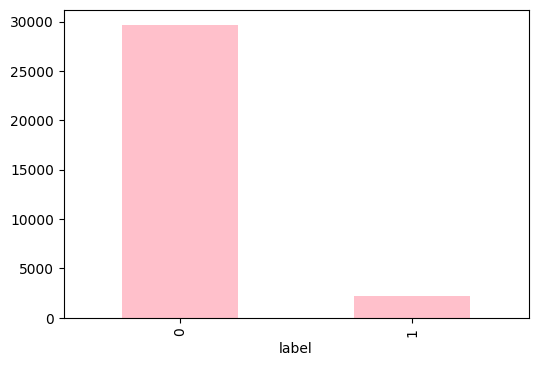

In [ ]:
train['label'].value_counts().plot.bar(color = 'pink', figsize = (6, 4))

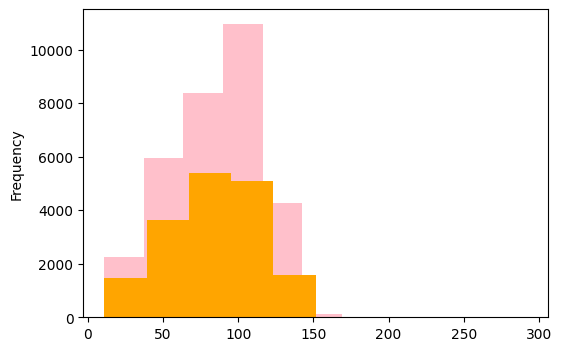

In [ ]:
# checking the distribution of tweets in the data

length_train = train['tweet'].str.len().plot.hist(color = 'pink', figsize = (6, 4))
length_test = test['tweet'].str.len().plot.hist(color = 'orange', figsize = (6, 4))

In [ ]:
# adding a column to represent the length of the tweet

train['len'] = train['tweet'].str.len()
test['len'] = test['tweet'].str.len()

train.head(10)

,id,label,tweet,len
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39
5,6,0,[2/2] huge fan fare and big talking before the...,116
6,7,0,@user camping tomorrow @user @user @user @use...,74
7,8,0,the next school year is the year for exams.ð...,143
8,9,0,we won!!! love the land!!! #allin #cavs #champ...,87
9,10,0,@user @user welcome here ! i'm it's so #gr...,50


In [ ]:

train.groupby('label').describe()

id                                                               \
         count          mean          std   min      25%      50%       75%   
label                                                                         
0      29720.0  15974.454441  9223.783469   1.0  7981.75  15971.5  23965.25   
1       2242.0  16074.896075  9267.955758  14.0  8075.25  16095.0  24022.00   

                    len                                                        
           max    count       mean        std   min   25%   50%    75%    max  
label                                                                          
0      31962.0  29720.0  84.328634  29.566484  11.0  62.0  88.0  107.0  274.0  
1      31961.0   2242.0  90.187779  27.375502  12.0  69.0  96.0  111.0  152.0

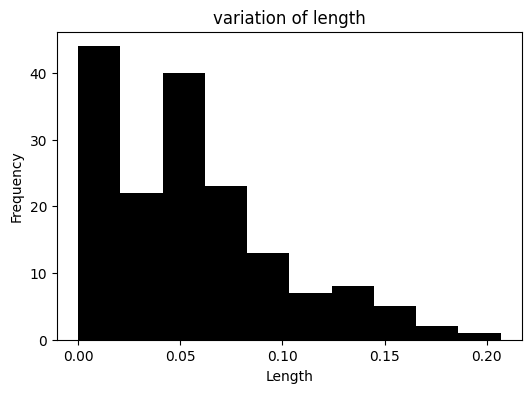

In [ ]:
train['label'] = train['label'].astype(float)
# Explicitly select numeric columns before grouping to avoid aggregation errors on text columns
train[['len', 'label']].groupby('len').mean()['label'].plot.hist(color = 'black', figsize = (6, 4))
plt.title('variation of length')
plt.xlabel('Length')
plt.show()

Text(0.5, 1.0, 'Most Frequently Occuring Words - Top 30')

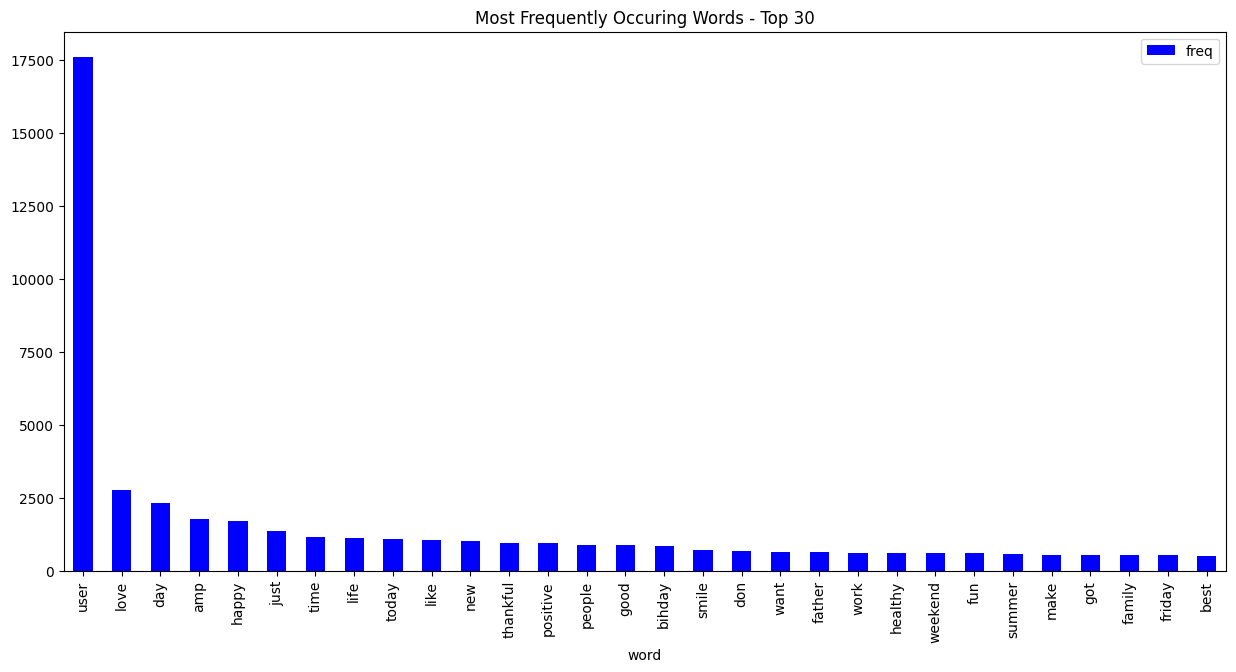

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


cv = CountVectorizer(stop_words = 'english')
words = cv.fit_transform(train.tweet)

sum_words = words.sum(axis=0)

words_freq = [(word, sum_words[0, i]) for word, i in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)

frequency = pd.DataFrame(words_freq, columns=['word', 'freq'])

frequency.head(30).plot(x='word', y='freq', kind='bar', figsize=(15, 7), color = 'blue')
plt.title("Most Frequently Occuring Words - Top 30")


Text(0.5, 1.0, 'WordCloud - Vocabulary from Reviews')

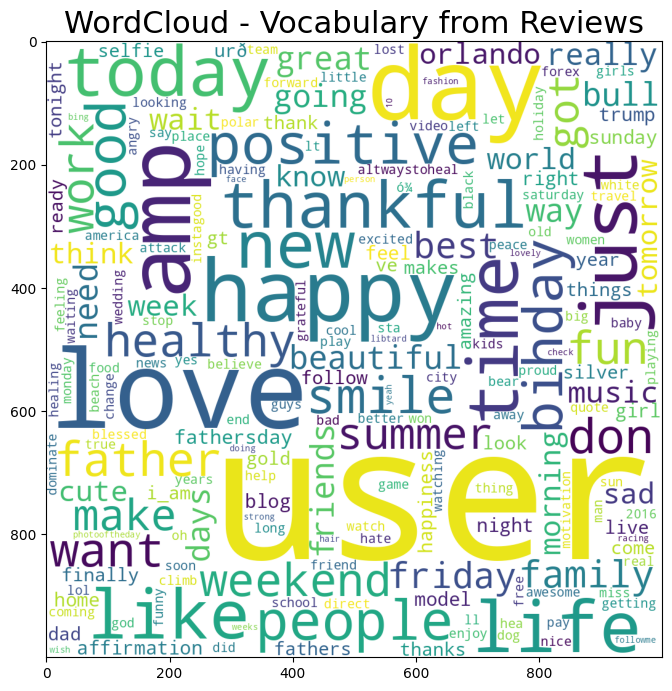

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(background_color = 'white', width = 1000, height = 1000).generate_from_frequencies(dict(words_freq))

plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.title("WordCloud - Vocabulary from Reviews", fontsize = 22)

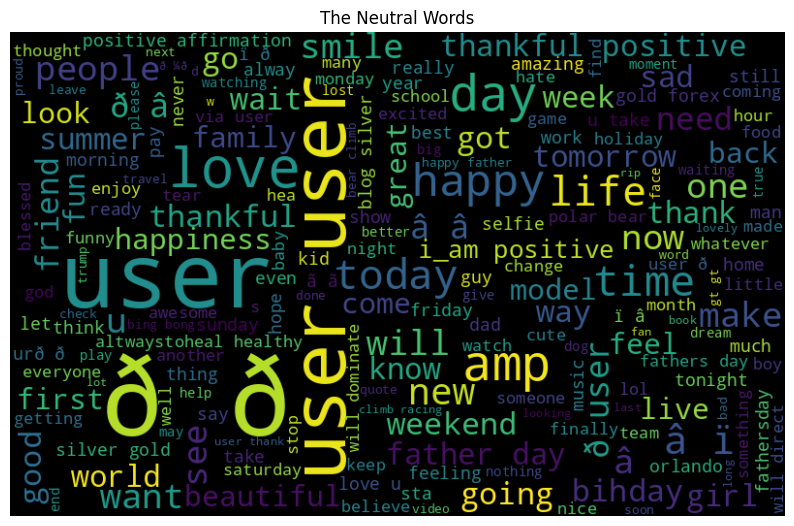

In [ ]:
normal_words =' '.join([text for text in train['tweet'][train['label'] == 0]])

wordcloud = WordCloud(width=800, height=500, random_state = 0, max_font_size = 110).generate(normal_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('The Neutral Words')
plt.show()


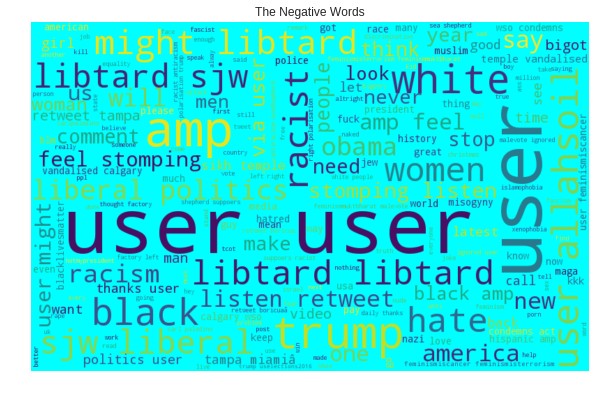

In [ ]:
negative_words =' '.join([text for text in train['tweet'][train['label'] == 1]])

wordcloud = WordCloud(background_color = 'cyan', width=800, height=500, random_state = 0, max_font_size = 110).generate(negative_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('The Negative Words')
plt.show()


In [ ]:
# collecting the hashtags
import re
def hashtag_extract(x):
    hashtags = []

    for i in x:
        ht = re.findall(r"#(\w+)", i)
        hashtags.append(ht)

    return hashtags

In [ ]:
# extracting hashtags from non racist/sexist tweets
HT_regular = hashtag_extract(train['tweet'][train['label'] == 0])

# extracting hashtags from racist/sexist tweets
HT_negative = hashtag_extract(train['tweet'][train['label'] == 1])

# unnesting list
HT_regular = sum(HT_regular,[])
HT_negative = sum(HT_negative,[])
HT_regular

In [ ]:
HT_negative

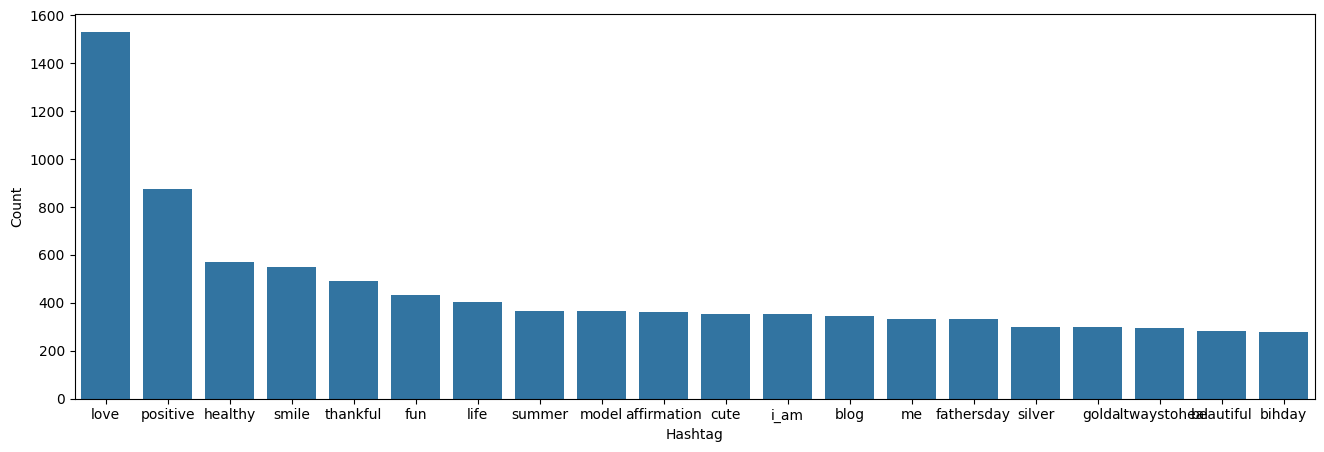

In [ ]:
import nltk
a = nltk.FreqDist(HT_regular)
d = pd.DataFrame({'Hashtag': list(a.keys()),
                  'Count': list(a.values())})

# selecting top 20 most frequent hashtags
d = d.nlargest(columns="Count", n = 20)
plt.figure(figsize=(16,5))
ax = sns.barplot(data=d, x= "Hashtag", y = "Count")
ax.set(ylabel = 'Count')
plt.show()

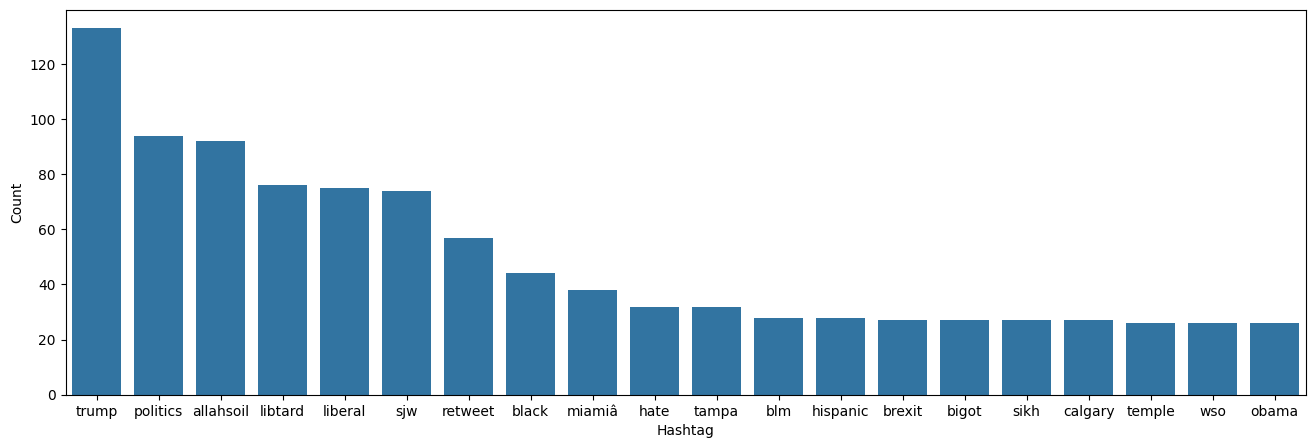

In [ ]:
a = nltk.FreqDist(HT_negative)
d = pd.DataFrame({'Hashtag': list(a.keys()),
                  'Count': list(a.values())})

# selecting top 20 most frequent hashtags
d = d.nlargest(columns="Count", n = 20)
plt.figure(figsize=(16,5))
ax = sns.barplot(data=d, x= "Hashtag", y = "Count")
ax.set(ylabel = 'Count')
plt.show()

In [ ]:
!pip install gensim

# tokenizing the words present in the training set
tokenized_tweet = train['tweet'].apply(lambda x: x.split())

# importing gensim Word2Vec ,Doc2Vec,FastText,LDA,TF-IDF
import gensim
from gensim.models import Word2Vec

# creating a word to vector model
model_w2v = Word2Vec(
            sentences=tokenized_tweet,
            vector_size=200, # desired no. of features/independent variables
            window=5, # context window size
            min_count=2,
            sg = 1, # 1 for skip-gram model#Uses the current word to predict the surrounding context words.
            hs = 0,
            negative = 10, # for negative sampling
            workers= 2, # no.of cores
            seed = 34)

model_w2v.train(tokenized_tweet, total_examples= len(train['tweet']), epochs=20)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.0 MB/s eta 0:00:00


(6109885, 8411580)

In [ ]:
model_w2v.wv.most_similar(positive = "dinner")

[('spaghetti', 0.6410127282142639),
 ('#prosecco', 0.6278508901596069),
 ('7!', 0.5972346663475037),
 ('sister!!', 0.5917893648147583),
 ('bay.', 0.5911545157432556),
 ('#wanderlust', 0.5734118223190308),
 ('shopping!', 0.5729155540466309),
 ('#chilled', 0.5705731511116028),
 ('willow', 0.5688662528991699),
 ('#sewingbee', 0.5683742761611938)]

In [ ]:
model_w2v.wv.most_similar(positive = "cancer")

[('ways.', 0.7240647673606873),
 ('ownership', 0.7182754874229431),
 ('level.', 0.7170885801315308),
 ('harassment', 0.708536684513092),
 ('champion,', 0.7046914100646973),
 ('tolerance', 0.7016633152961731),
 ('solution', 0.698945164680481),
 ('britain', 0.6965237259864807),
 ('law.', 0.6911390423774719),
 ('#survivor', 0.6883094310760498)]

In [ ]:
model_w2v.wv.most_similar(positive = "apple")

[('mytraining', 0.6982271671295166),
 ('"mytraining"', 0.6974446177482605),
 ('training"', 0.6756565570831299),
 ('app,', 0.6172770261764526),
 ('"my', 0.5907898545265198),
 ('mp3', 0.5757710337638855),
 ('ta', 0.5560265183448792),
 ('app', 0.553641676902771),
 ("domino's", 0.544304370880127),
 ('"childish".', 0.5436285734176636)]

In [ ]:
model_w2v.wv.most_similar(negative = "hate")

[('â\x9c\x88ï¸\x8f', 0.03646264597773552),
 ('#community', 0.02715616300702095),
 ('#tgif', 0.023397646844387054),
 ('#progress', 0.01606094464659691),
 ('â\x99¡', 0.013728323392570019),
 ('#foodie', 0.01064552552998066),
 ('ð\x9f\x92\x8b', 0.00944315642118454),
 ('#inlove', 0.005434214137494564),
 ('de', 0.005008651874959469),
 ('#fridayfeeling', 0.004233125597238541)]

In [ ]:
from tqdm import tqdm
tqdm.pandas(desc="progress-bar")
from gensim.models.doc2vec import TaggedDocument

In [ ]:
def add_label(twt):
    output = []
    for i, s in zip(twt.index, twt):
        # Changed LabeledSentence to TaggedDocument for Gensim 4.0+
        output.append(TaggedDocument(s, ["tweet_" + str(i)]))
    return output

# label all the tweets
labeled_tweets = add_label(tokenized_tweet)

labeled_tweets[:6]

[TaggedDocument(words=['@user', 'when', 'a', 'father', 'is', 'dysfunctional', 'and', 'is', 'so', 'selfish', 'he', 'drags', 'his', 'kids', 'into', 'his', 'dysfunction.', '#run'], tags=['tweet_0']),
 TaggedDocument(words=['@user', '@user', 'thanks', 'for', '#lyft', 'credit', 'i', "can't", 'use', 'cause', 'they', "don't", 'offer', 'wheelchair', 'vans', 'in', 'pdx.', '#disapointed', '#getthanked'], tags=['tweet_1']),
 TaggedDocument(words=['bihday', 'your', 'majesty'], tags=['tweet_2']),
 TaggedDocument(words=['#model', 'i', 'love', 'u', 'take', 'with', 'u', 'all', 'the', 'time', 'in', 'urð\x9f\x93±!!!', 'ð\x9f\x98\x99ð\x9f\x98\x8eð\x9f\x91\x84ð\x9f\x91', 'ð\x9f\x92¦ð\x9f\x92¦ð\x9f\x92¦'], tags=['tweet_3']),
 TaggedDocument(words=['factsguide:', 'society', 'now', '#motivation'], tags=['tweet_4']),
 TaggedDocument(words=['[2/2]', 'huge', 'fan', 'fare', 'and', 'big', 'talking', 'before', 'they', 'leave.', 'chaos', 'and', 'pay', 'disputes', 'when', 'they', 'get', 'there.', '#allshowandnogo'],

In [ ]:
# removing unwanted patterns from the data

import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
train_corpus = []

for i in range(0, 31962):
  review = re.sub('[^a-zA-Z]', ' ', train['tweet'][i])
  review = review.lower()
  review = review.split()

  ps = PorterStemmer()

  # stemming
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]

  # joining them back with space
  review = ' '.join(review)
  train_corpus.append(review)

In [ ]:
test_corpus = []

for i in range(0, 17197):
  review = re.sub('[^a-zA-Z]', ' ', test['tweet'][i])
  review = review.lower()
  review = review.split()

  ps = PorterStemmer()

  # stemming
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]

  # joining them back with space
  review = ' '.join(review)
  test_corpus.append(review)

In [ ]:
# creating bag of words

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 2500)
x = cv.fit_transform(train_corpus).toarray()
y = train.iloc[:, 1]

print(x.shape)
print(y.shape)


(31962, 2500)
(31962,)


In [ ]:
# creating bag of words

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 2500)
x_test = cv.fit_transform(test_corpus).toarray()

print(x_test.shape)


(17197, 2500)


In [ ]:
# splitting the training data into train and valid sets

from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size = 0.25, random_state = 42)

print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(23971, 2500)
(7991, 2500)
(23971,)
(7991,)


In [ ]:
# standardization

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_valid = sc.transform(x_valid)
x_test = sc.transform(x_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_valid)

print("Training Accuracy :", model.score(x_train, y_train))
print("Validation Accuracy :", model.score(x_valid, y_valid))

# calculating the f1 score for the validation set
print("F1 score :", f1_score(y_valid, y_pred))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred)
print(cm)



Training Accuracy : 0.999123941429227
Validation Accuracy : 0.9538230509322988
F1 score : 0.6230847803881512
[[7317  115]
 [ 254  305]]


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_valid)

print("Training Accuracy :", model.score(x_train, y_train))
print("Validation Accuracy :", model.score(x_valid, y_valid))

# calculating the f1 score for the validation set
print("f1 score :", f1_score(y_valid, y_pred))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred)
print(cm)


Training Accuracy : 0.9852738725960536
Validation Accuracy : 0.9405581278938806
f1 score : 0.5865970409051349
[[7179  253]
 [ 222  337]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_valid)

print("Training Accuracy :", model.score(x_train, y_train))
print("Validation Accuracy :", model.score(x_valid, y_valid))

# calculating the f1 score for the validation set
print("f1 score :", f1_score(y_valid, y_pred))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred)
print(cm)


Training Accuracy : 0.9991656585040257
Validation Accuracy : 0.9297960205230885
f1 score : 0.5305439330543933
[[7113  319]
 [ 242  317]]


In [ ]:
from sklearn.svm import SVC

model = SVC()
model.fit(x_train, y_train)

y_pred = model.predict(x_valid)

print("Training Accuracy :", model.score(x_train, y_train))
print("Validation Accuracy :", model.score(x_valid, y_valid))

# calculating the f1 score for the validation set
print("f1 score :", f1_score(y_valid, y_pred))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred)
print(cm)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_valid)

print("Training Accuracy :", model.score(x_train, y_train))
print("Validation Accuracy :", model.score(x_valid, y_valid))

# calculating the f1 score for the validation set
print("f1 score :", f1_score(y_valid, y_pred))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred)
print(cm)

In [ ]:
# ==========================================
# VADER Sentiment Analysis on Twitter Dataset
# ==========================================

import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Download VADER lexicon (Run only once)
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# ------------------------------------------
# Load Dataset
# ------------------------------------------

# Replace with your CSV file path
df = pd.read_csv("/content/drive/MyDrive/TEJASHREE K/Certified Data Science/05-Advance Data Science/LMS_ADS-6-Sentiment Analysis/test_tweets.csv")

# Display available columns
print("Columns in Dataset:")
print(df.columns)

# ------------------------------------------
# Select Twitter Text Column
# ------------------------------------------

# Change 'text' if your column has another name
text_column = "tweet"

# ------------------------------------------
# Function to Analyze Sentiment
# ------------------------------------------

def analyze_sentiment(tweet):

    tweet = str(tweet)

    scores = sia.polarity_scores(tweet)

    compound = scores['compound']

    if compound >= 0.05:
        sentiment = "Positive"

    elif compound <= -0.05:
        sentiment = "Negative"

    else:
        sentiment = "Neutral"

    return pd.Series([
        scores['neg'],
        scores['neu'],
        scores['pos'],
        compound,
        sentiment
    ])

# ------------------------------------------
# Apply VADER
# ------------------------------------------

df[['Negative',
    'Neutral',
    'Positive',
    'Compound',
    'Sentiment']] = df[text_column].apply(analyze_sentiment)

# ------------------------------------------
# Display Results
# ------------------------------------------

print("\nFirst 10 Records\n")

print(df.head(10))

# ------------------------------------------
# Count Sentiments
# ------------------------------------------

print("\nSentiment Distribution\n")

print(df['Sentiment'].value_counts())

# ------------------------------------------
# Save Results
# ------------------------------------------

output_file = "twitter_vader_output.csv"

df.to_csv(output_file, index=False)

print(f"\nResults saved to {output_file}")

# ------------------------------------------
# Visualization
# ------------------------------------------

counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(counts.index, counts.values)

plt.title("Twitter Sentiment Analysis using VADER")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
Sentence
     ↓
Split into Words
     ↓
Look Up Lexicon
     ↓
Calculate Polarity
     ↓
Return Polarity & Subjectivity////Text blob

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

text = input("Enter your tweet: ")

score = sia.polarity_scores(text)

print(score)

if score['compound'] >= 0.05:
    print("Prediction: Positive")
elif score['compound'] <= -0.05:
    print("Prediction: Negative")
else:
    print("Prediction: Neutral")

In [ ]:
Sentence
     ↓
Split into Words
     ↓
Look Up Lexicon
     ↓
Check:
   • Negation ("not")
   • Intensifiers ("very", "extremely")
   • Capitalization ("LOVE")
   • Punctuation ("!!!")
   • Emojis & emoticons
     ↓
Adjust Scores
     ↓
Return Positive, Negative, Neutral, Compound//vader

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Test text (blob)
text_blob = """
I absolutely love this phone.
The camera is amazing and the battery life is excellent.
"""

# Analyze sentiment
scores = sia.polarity_scores(text_blob)

print("Negative :", scores['neg'])
print("Neutral  :", scores['neu'])
print("Positive :", scores['pos'])
print("Compound :", scores['compound'])

# Prediction
if scores['compound'] >= 0.05:
    print("Prediction : Positive")
elif scores['compound'] <= -0.05:
    print("Prediction : Negative")
else:
    print("Prediction : Neutral")

In [ ]:
import nltk
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK resources
nltk.download('opinion_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

positive = set(opinion_lexicon.positive())
negative = set(opinion_lexicon.negative())

text = input("Enter a sentence: ")

tokens = word_tokenize(text.lower())

positive_score = 0
negative_score = 0

for word in tokens:
    if word in string.punctuation:
        continue

    if word in positive:
        positive_score += 1

    elif word in negative:
        negative_score += 1

score = positive_score - negative_score

if score > 0:
    sentiment = "Positive"

elif score < 0:
    sentiment = "Negative"

else:
    sentiment = "Neutral"

print("\nPositive Score:", positive_score)
print("Negative Score:", negative_score)
print("Sentiment Score:", score)
print("Final Sentiment:", sentiment)

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Enter a sentence: 

Positive Score: 0
Negative Score: 0
Sentiment Score: 0
Final Sentiment: Neutral


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# User enters a tweet
text_blob = input("Enter a Tweet: ")

scores = sia.polarity_scores(text_blob)

print("\nScores")
print(scores)

if scores['compound'] >= 0.05:
    print("Predicted Label : 1 (Positive)")
else:
    print("Predicted Label : 0 (Negative)")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Enter a Tweet: hi how are you?

Scores
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Predicted Label : 0 (Negative)
